**Quotes Webscraper Notebook**

The primary objective of the Quotes Webscraper Notebook is to demonstrate an end-to-end workflow for AI-powered web scraping by combining traditional web fetching with Groq's fast LLM inference.

Core Objectives:

- Automate Unstructured Data Extraction: Fetch raw, semi-structured HTML content from a website "([http://quotes.toscrape.com/](http://quotes.toscrape.com/))" and convert it into structured, machine-readable JSON using Groq.

- Optimize Token Efficiency: Strip out unnecessary HTML noise "(such as script and style> tags" using BeautifulSoup before sending text to the LLM, keeping context window usage low and API execution fast.

- Guarantee Structured Output: Enforce strict JSON output (response_format={"type": "json_object"}) so extracted data (quotes and authors) can be immediately ingested into downstream apps or databases without manual parsing.

- Benchmark & Evaluate: Provide a reliable blueprint to measure execution speed, extraction accuracy, and structural validity.

**Dependency Installation**

In [6]:
!pip install groq requests beautifulsoup4 | tail -n 1

**Dependency Import**

In [8]:
import os
from groq import Groq
import requests
from bs4 import BeautifulSoup

**Initialize groq**

In [7]:
import os
from google.colab import userdata
# 1. Set Groq API Key
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
# Initialize Groq Client
client = Groq()

**Fetching the Target Web Page**

In [9]:
# 1. Fetch Web Page
url = "http://quotes.toscrape.com/"
response = requests.get(url)

**Cleaning the HTML (Token Optimization)**

In [10]:
# 2. Clean HTML (Strip scripts/styles to save tokens)
soup = BeautifulSoup(response.text, 'html.parser')
for element in soup(["script", "style"]):
    element.decompose()
cleaned_text = soup.get_text(separator=' ', strip=True)[:4000] # Truncate if needed

# 3. Use Groq to Extract Structured Data
prompt = f"Extract all quotes and authors from the following text into valid JSON:\n\n{cleaned_text}"

completion = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[{"role": "user", "content": prompt}],
    response_format={"type": "json_object"}
)

print(completion.choices[0].message.content)

[
{"quote":"The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.","author":"Albert Einstein"},{"quote":"It is our choices, Harry, that show what we truly are, far more than our abilities.","author":"J.K. Rowling"},{"quote":"There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.","author":"Albert Einstein"},{"quote":"The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.","author":"Jane Austen"},{"quote":"Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.","author":"Marilyn Monroe"},{"quote":"Try not to become a man of success. Rather become a man of value.","author":"Albert Einstein"},{"quote":"It is better to be hated for what you are than to be loved for what you are not.","author":"Andr\u00e9 Gide"},{"quote":"I have not failed. I've just found 

**Evaluation**

Evaluating involves assessing correctness, execution speed, token efficiency, and output quality.

**1. Functional Verification (Step-by-Step Debugging)**

In [16]:
# Check 1: Did the website respond?
print(f"HTTP Status: {response.status_code}") # Should output 200

# Check 2: Was HTML cleaned effectively?
print(f"Raw HTML length: {len(response.text)}")
print(f"Cleaned Text length: {len(cleaned_text)}")
print("First 200 characters of clean text:\n", cleaned_text[:200])

# Check 3: Did Groq return valid JSON?
import json
try:
    data = json.loads(completion.choices[0].message.content)
    print("Valid JSON parsed successfully!")
    print(f"Extracted {len(data)} quotes.")
except json.JSONDecodeError as e:
    print("Failed to parse output as JSON:", e)

HTTP Status: 200
Raw HTML length: 11021
Cleaned Text length: 1681
First 200 characters of clean text:
 Quotes to Scrape Quotes to Scrape Login “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” by Albert Einstein (about) Tags: change deep
Valid JSON parsed successfully!
Extracted 10 quotes.


**2. Measuring Latency & Performance**

In [18]:
# Benchmark the web fetch time vs Groq inference time
%time http_res = requests.get("http://quotes.toscrape.com/")
%time groq_res = client.chat.completions.create(model="openai/gpt-oss-120b", messages=[{"role": "user", "content": prompt}], response_format={"type": "json_object"})

CPU times: user 1.86 ms, sys: 841 µs, total: 2.7 ms
Wall time: 8.32 ms
CPU times: user 7.79 ms, sys: 1.11 ms, total: 8.9 ms
Wall time: 1.59 s


**3. Key Metrics to Evaluate**

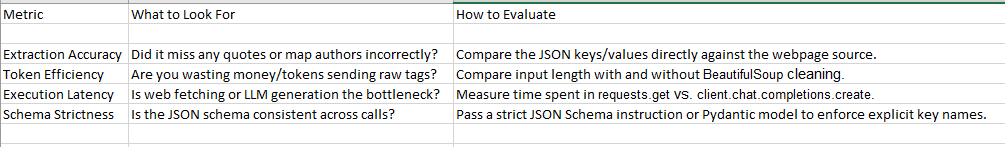

**4. Automated Evaluation Script**

In [19]:
import time
import json

start_time = time.time()

# 1. Fetch & Clean
res = requests.get("http://quotes.toscrape.com/")
soup = BeautifulSoup(res.text, 'html.parser')
for el in soup(["script", "style"]):
    el.decompose()
text = soup.get_text(separator=' ', strip=True)[:4000]

# 2. Extract with Groq
completion = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[{"role": "user", "content": f"Extract all quotes and authors into JSON format with key 'items':\n\n{text}"}],
    response_format={"type": "json_object"}
)

elapsed_time = time.time() - start_time

# 3. Output Evaluation Summary
raw_output = completion.choices[0].message.content
parsed = json.loads(raw_output)

print("=== EVALUATION REPORT ===")
print(f"Total Latency    : {elapsed_time:.2f} seconds")
print(f"Clean Text Length: {len(text)} characters")
print(f"Valid JSON Output: {isinstance(parsed, dict)}")
print(f"Items Extracted  : {len(parsed.get('items', parsed))}")

=== EVALUATION REPORT ===
Total Latency    : 2.38 seconds
Clean Text Length: 1681 characters
Valid JSON Output: True
Items Extracted  : 10
